# Full ML Pipeline Demo

End-to-end: preprocessing → feature selection → model → calibration → evaluation.

In [1]:
import sys
import os

# Menambahkan folder utama ke daftar pencarian Python
sys.path.append(os.path.abspath("..")) 

import mlengine as mle
print(mle.__version__)

0.1.0


In [2]:
import numpy as np
import mlengine as mle
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Simulated messy dataset
rng = np.random.default_rng(42)
X, y = make_classification(n_samples=1000, n_features=30, n_informative=10,
                             n_redundant=5, random_state=42)
# Inject missing values
mask = rng.random(X.shape) < 0.05
X[mask] = np.nan
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training set: {X_tr.shape}, missing: {np.isnan(X_tr).sum()} values')

Training set: (800, 30), missing: 1203 values


## Full Pipeline with Imputation + Scaling + Feature Selection + Classifier

In [3]:
pipe = mle.make_pipeline(
    mle.SimpleImputer(strategy='mean'),
    mle.StandardScaler(),
    mle.SelectKBest(k=15),
    mle.RandomForest(n_estimators=100, max_depth=6, random_state=42),
)
pipe.fit(X_tr, y_tr)
print(f'Pipeline accuracy: {pipe.score(X_te, y_te):.4f}')

Pipeline accuracy: 0.8900


## GridSearchCV over Full Pipeline

In [4]:
from mlengine.preprocessing import SimpleImputer
from mlengine.evaluation import GridSearchCV

# Impute first (GridSearchCV doesn't handle NaN in input)
imp = SimpleImputer().fit(X_tr)
X_tr_clean = imp.transform(X_tr)
X_te_clean = imp.transform(X_te)

grid = GridSearchCV(
    mle.GradientBoostingClassifier(n_estimators=50),
    param_grid={'learning_rate': [0.05, 0.1, 0.2], 'max_depth': [2, 3]},
    cv=3, scoring='accuracy',
)
grid.fit(X_tr_clean, y_tr)
print(f'Best params:  {grid.best_params_}')
print(f'Best CV score: {grid.best_score_:.4f}')
print(f'Test score:    {grid.score(X_te_clean, y_te):.4f}')

Best params:  {'learning_rate': 0.2, 'max_depth': 3}
Best CV score: 0.8475
Test score:    0.8800


## Probability Calibration

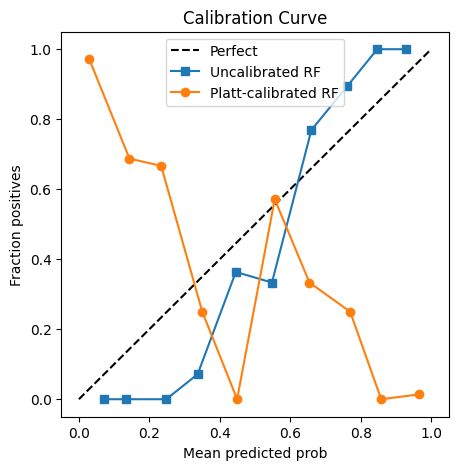

In [5]:
from mlengine.evaluation import CalibratedClassifier, calibration_curve
import matplotlib.pyplot as plt

base_clf = mle.RandomForest(n_estimators=50, random_state=0)
cal_clf  = CalibratedClassifier(mle.RandomForest(n_estimators=50, random_state=0),
                                  method='platt', cv=5)
base_clf.fit(X_tr_clean, y_tr)
cal_clf.fit(X_tr_clean, y_tr)

frac_base, mean_base = calibration_curve(y_te, base_clf.predict_proba(X_te_clean)[:,1])
frac_cal,  mean_cal  = calibration_curve(y_te, cal_clf.predict_proba(X_te_clean)[:,1])

plt.figure(figsize=(5,5))
plt.plot([0,1],[0,1],'k--',label='Perfect')
plt.plot(mean_base, frac_base, 's-', label='Uncalibrated RF')
plt.plot(mean_cal,  frac_cal,  'o-', label='Platt-calibrated RF')
plt.xlabel('Mean predicted prob'); plt.ylabel('Fraction positives')
plt.title('Calibration Curve'); plt.legend(); plt.show()

## FeatureUnion: Combine PCA + SelectKBest

In [6]:
union_pipe = mle.make_pipeline(
    mle.SimpleImputer(),
    mle.StandardScaler(),
    mle.FeatureUnion([
        ('pca', mle.PCA(n_components=5)),
        ('kbest', mle.SelectKBest(k=5)),
    ]),
    mle.LogisticRegression(C=1.0, n_iter=500),
)
union_pipe.fit(X_tr, y_tr)
print(f'Union pipeline accuracy: {union_pipe.score(X_te, y_te):.4f}')

Union pipeline accuracy: 0.8150
